# ANN-Based Customer Churn Prediction

This notebook develops an Artificial Neural Network (ANN) model to predict customer churn using the provided dataset.

## Objectives
- Load and inspect the dataset
- Preprocess numerical and categorical features
- Build and train an ANN model
- Evaluate predictive performance
- Generate churn probability-based customer risk segments
- Save the trained model and supporting artifacts

## Workflow
1. Import libraries  
2. Load and inspect the dataset  
3. Define features and target  
4. Identify numerical and categorical columns  
5. Build preprocessing pipeline  
6. Split the data  
7. Apply preprocessing  
8. Define ANN architecture  
9. Train the model  
10. Evaluate model performance  
11. Visualize results  
12. Create customer risk segments  
13. Save outputs

## Step 1: Import Libraries

This step imports the required libraries for:
- data handling
- preprocessing
- model development
- evaluation
- visualization
- saving artifacts

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.19.0


## Step 2: Load and Inspect the Dataset

This step loads the uploaded dataset and checks:
- dataset dimensions
- preview of records
- data types
- missing values
- target distribution

In [3]:
df = pd.read_csv("Dataset_ATS_v2.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Churn"].value_counts())

Dataset shape: (7043, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No



Column names:
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn']

Data types:
gender             object
SeniorCitizen       int64
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
Contract           object
MonthlyCharges      int64
Churn              object
dtype: object

Missing values:
gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### Churn Distribution
This visualization shows the proportion of customers who churned versus those who remained.

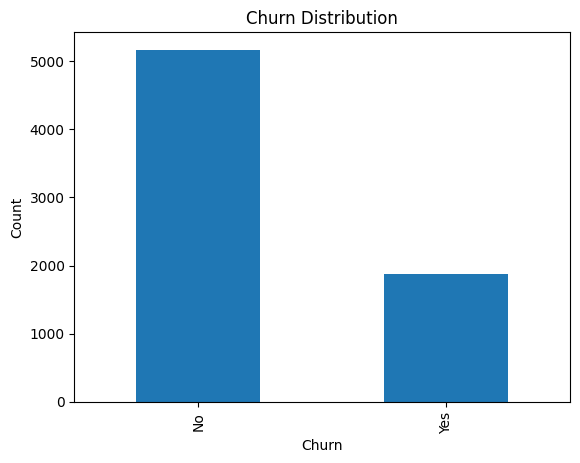

In [21]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

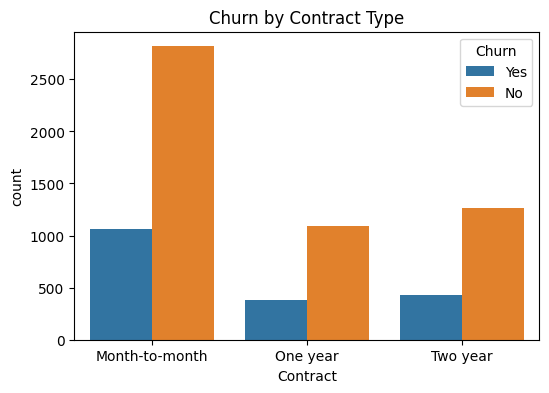

In [22]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

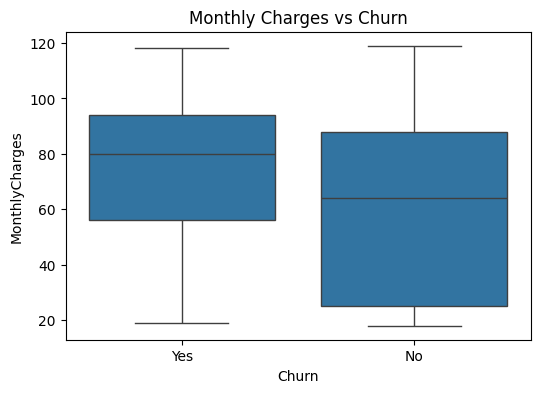

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

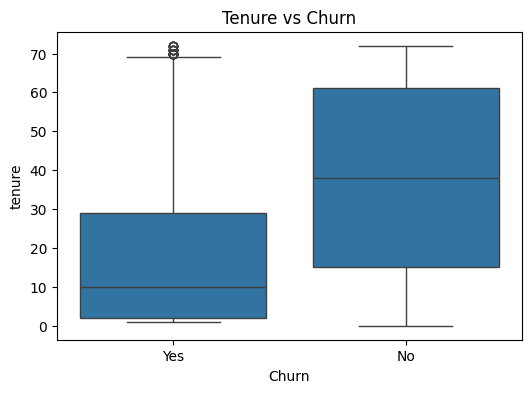

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

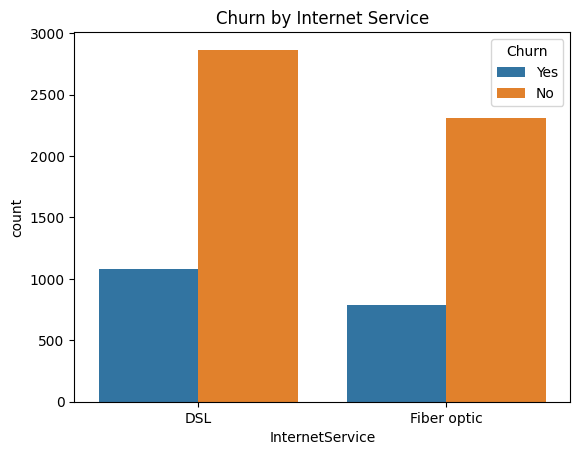

In [25]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

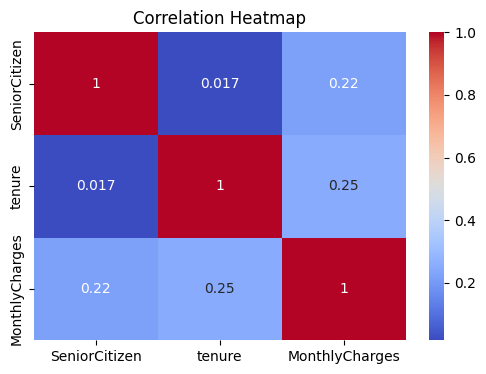

In [26]:
plt.figure(figsize=(6,4))
corr = df.select_dtypes(include=["int64","float64"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Step 3: Define Features and Target Variable

The target variable is `Churn`, which indicates whether a customer has left the service.

All remaining columns are used as input features.

In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)   # No = 0, Yes = 1

print("Encoded target classes:", list(label_encoder.classes_))
print("Feature columns:")
print(X.columns.tolist())

Encoded target classes: ['No', 'Yes']
Feature columns:
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges']


## Step 4: Identify Numerical and Categorical Columns

This step separates features into:
- numerical columns for scaling
- categorical columns for encoding

In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


## Step 5: Build the Preprocessing Pipeline

The preprocessing strategy is:
- standardize numerical variables using `StandardScaler`
- one-hot encode categorical variables using `OneHotEncoder`

This ensures all input features are suitable for ANN training.

In [7]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Step 6: Split the Dataset into Training and Test Sets

The dataset is split into:
- 80% training data
- 20% testing data

Stratified sampling is used to preserve the class distribution of churn.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (5634, 9)
Test set shape: (1409, 9)


## Step 7: Apply Preprocessing to the Data

The preprocessing pipeline is fitted on the training data and then applied to both training and testing datasets.

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (5634, 10)
Processed test shape: (1409, 10)


## Step 8: Define the ANN Architecture

The ANN architecture is designed as follows:

- Input layer based on the transformed feature dimension
- First hidden layer with 32 neurons and ReLU activation
- Dropout layer with rate 0.30
- Second hidden layer with 16 neurons and ReLU activation
- Dropout layer with rate 0.20
- Output layer with 1 neuron and sigmoid activation

The sigmoid output produces churn probabilities between 0 and 1.

In [10]:
input_dim = X_train_processed.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

## Step 9: Train the ANN Model

The model is trained using:
- binary crossentropy loss
- Adam optimizer
- accuracy as the evaluation metric

Early stopping is used to prevent overfitting by monitoring validation loss.

In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7380 - loss: 0.5263 - val_accuracy: 0.7853 - val_loss: 0.4582
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7650 - loss: 0.4707 - val_accuracy: 0.7995 - val_loss: 0.4416
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7721 - loss: 0.4643 - val_accuracy: 0.7888 - val_loss: 0.4393
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7724 - loss: 0.4637 - val_accuracy: 0.7941 - val_loss: 0.4393
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7801 - loss: 0.4630 - val_accuracy: 0.7906 - val_loss: 0.4368
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7792 - loss: 0.4577 - val_accuracy: 0.7977 - val_loss: 0.4372
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7797 - loss: 0.4585 - val_accuracy: 0.8004 - val_loss: 0.4346
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7801 - loss: 0.4566 - val_accuracy: 0.

## Step 10: Generate Predictions and Evaluate Performance

This step calculates:
- predicted churn probabilities
- binary predictions
- accuracy
- precision
- recall
- F1-score
- ROC-AUC

In [13]:
y_pred_prob = model.predict(X_test_processed).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy : 0.7892
Precision: 0.641
Recall   : 0.4679
F1 Score : 0.541
ROC-AUC  : 0.8062

Classification Report:

              precision    recall  f1-score   support

          No       0.82      0.91      0.86      1035
         Yes       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## Step 11: Visualize the Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified as churners and non-churners.

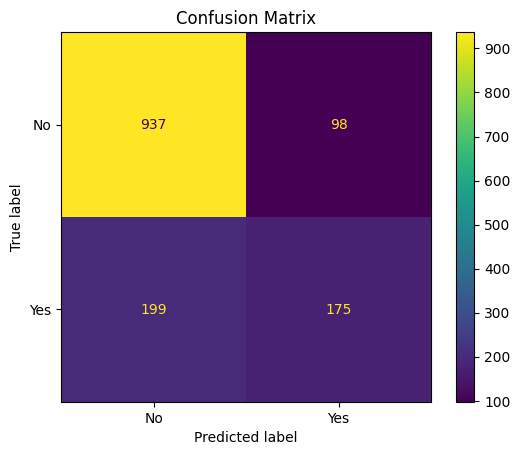

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


## Step 12: Plot Training and Validation Loss

This plot helps assess:
- learning progress
- convergence
- potential overfitting

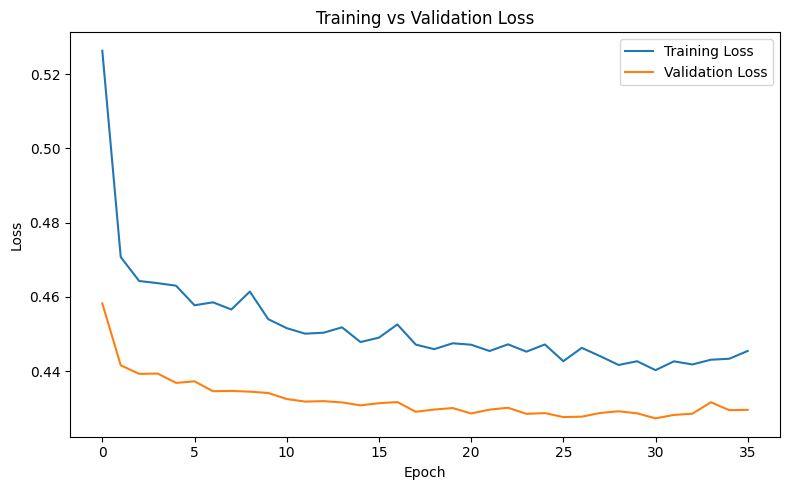

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Step 13: Plot Training and Validation Accuracy

This plot compares model performance on the training and validation datasets during learning.

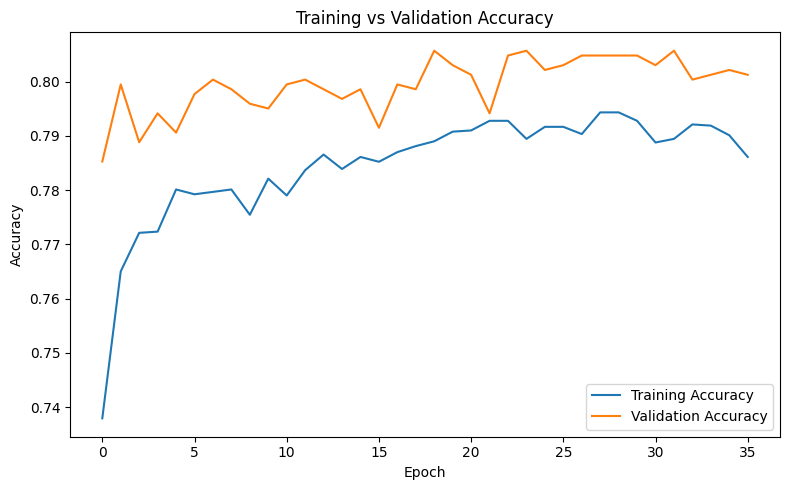

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Step 14: Plot the ROC Curve

The ROC curve evaluates the model's ability to distinguish between churners and non-churners across classification thresholds.

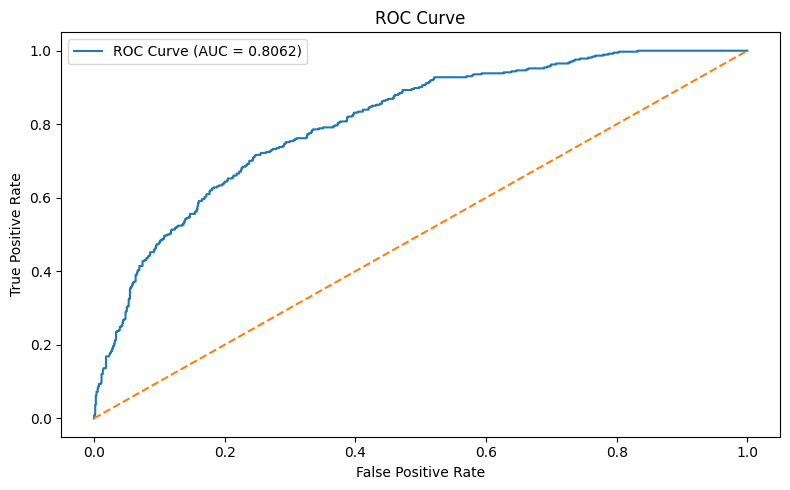

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Step 15: Create Customer Risk Segments

Customers are segmented based on predicted churn probability:

- High Risk: probability greater than or equal to 0.70
- Medium Risk: probability from 0.40 to less than 0.70
- Low Risk: probability below 0.40

This segmentation supports targeted retention planning.

In [19]:
risk_df = X_test.copy().reset_index(drop=True)
risk_df["Actual_Churn"] = y_test
risk_df["Predicted_Probability"] = y_pred_prob

def assign_risk(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Segment"] = risk_df["Predicted_Probability"].apply(assign_risk)
risk_df["Actual_Churn"] = risk_df["Actual_Churn"].map({1: "Yes", 0: "No"})

display(risk_df.head())

print("\nRisk segment distribution:")
print(risk_df["Risk_Segment"].value_counts())

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Actual_Churn,Predicted_Probability,Risk_Segment
0,Female,1,No,2,Yes,No,Fiber optic,One year,84,No,0.728179,High Risk
1,Male,0,No,20,Yes,Yes,Fiber optic,Month-to-month,64,No,0.260691,Low Risk
2,Male,0,Yes,43,Yes,No,DSL,One year,19,No,0.018513,Low Risk
3,Male,0,Yes,44,No,Yes,Fiber optic,Month-to-month,54,No,0.099246,Low Risk
4,Male,0,No,19,Yes,No,DSL,Two year,20,No,0.044808,Low Risk



Risk segment distribution:
Risk_Segment
Low Risk       1017
Medium Risk     325
High Risk        67
Name: count, dtype: int64


## Step 16: Save the Model and Supporting Files

The following files are saved:
- trained ANN model
- preprocessing pipeline
- target label encoder
- customer risk segmentation output

In [20]:
model.save("ann_churn_model.h5")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(label_encoder, "target_label_encoder.pkl")
risk_df.to_csv("customer_risk_segmentation.csv", index=False)

print("Files saved successfully:")
print("- ann_churn_model.h5")
print("- preprocessor.pkl")
print("- target_label_encoder.pkl")
print("- customer_risk_segmentation.csv")

Files saved successfully:
- ann_churn_model.h5
- preprocessor.pkl
- target_label_encoder.pkl
- customer_risk_segmentation.csv


## Step 17: Conclusion

This notebook successfully:
- prepared the customer dataset
- trained an ANN model for churn prediction
- evaluated predictive performance
- generated customer churn risk segments

The next phase will focus on:
- identifying factors contributing to churn and retention
- summarizing key findings
- developing targeted retention recommendations
- documenting project limitations and proposed improvements